In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns

print("✅ Все библиотеки успешно загружены!")
print("Версия Python:", __import__('sys').version.split()[0])

✅ Все библиотеки успешно загружены!
Версия Python: 3.12.3


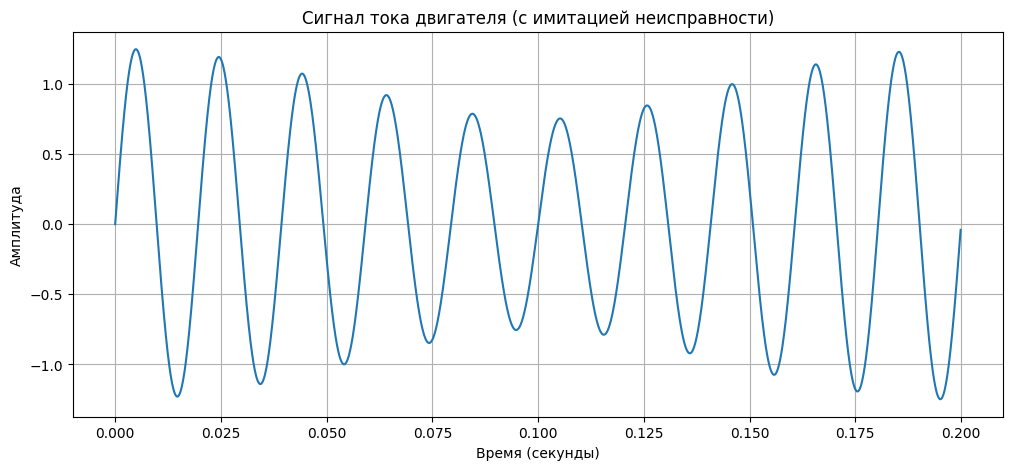

In [2]:
# Параметры сигнала (соответствуют нашему ТЗ)
fs = 10000                    # частота дискретизации 10 кГц
t = np.arange(0, 2.0, 1/fs)   # 2 секунды сигнала
f0 = 50                       # основная частота 50 Гц

# Имитация сигнала тока двигателя
signal_clean = np.sin(2 * np.pi * f0 * t)
noise = np.random.normal(0, 0.05, len(t))

# Имитация неисправности (боковая полоса)
signal_faulty = signal_clean + 0.25 * np.sin(2 * np.pi * 55 * t)

# График сигнала во времени
plt.figure(figsize=(12, 5))
plt.plot(t[:2000], signal_faulty[:2000])
plt.title("Сигнал тока двигателя (с имитацией неисправности)")
plt.xlabel("Время (секунды)")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.show()

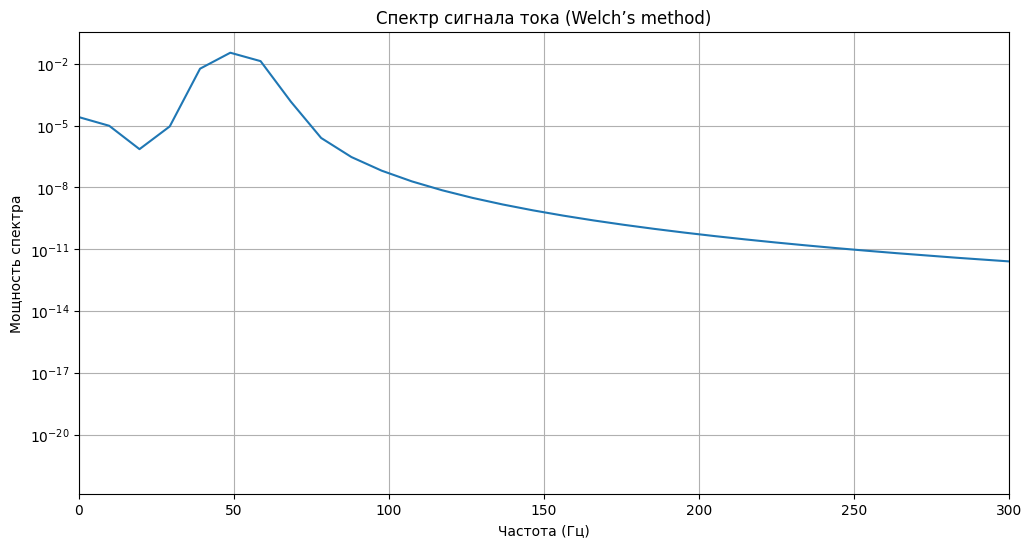

Основные частоты в спектре:
Частота 1: 48.83 Гц  (мощность: 0.0344)


In [3]:
# Выполняем Welch’s method — основной метод спектрального анализа в MCSA
f, Pxx = signal.welch(signal_faulty, fs=fs, nperseg=1024)

# Строим спектр
plt.figure(figsize=(12, 6))
plt.semilogy(f, Pxx)
plt.title("Спектр сигнала тока (Welch’s method)")
plt.xlabel("Частота (Гц)")
plt.ylabel("Мощность спектра")
plt.grid(True)
plt.xlim(0, 300)          # смотрим до 300 Гц
plt.show()

# Находим основные пики в спектре
peaks, properties = signal.find_peaks(Pxx, height=0.001)
print("Основные частоты в спектре:")
for i, peak in enumerate(peaks[:8]):
    print(f"Частота {i+1}: {f[peak]:.2f} Гц  (мощность: {properties['peak_heights'][i]:.4f})")

In [4]:
# Извлечение MCSA-признаков (основные для нашего проекта)

# 1. RMS тока (среднеквадратичное значение)
rms_current = np.sqrt(np.mean(signal_faulty**2))
print(f"RMS ток: {rms_current:.4f}")

# 2. Основная частота (50 Гц)
main_freq = 50

# 3. Амплитуда боковых полос (имитация неисправности ротора)
sideband_left = 50 - 2*2.5   # (1 - 2s)f ≈ 45 Гц
sideband_right = 50 + 2*2.5  # (1 + 2s)f ≈ 55 Гц

# Поиск мощности на боковых полосах
idx_left = np.argmin(np.abs(f - sideband_left))
idx_right = np.argmin(np.abs(f - sideband_right))

print(f"Левая боковая полоса ({sideband_left} Гц): {Pxx[idx_left]:.6f}")
print(f"Правая боковая полоса ({sideband_right} Гц): {Pxx[idx_right]:.6f}")

# 4. Дисбаланс фаз (пока имитируем)
current_imbalance = np.random.uniform(0.5, 3.0)   # в процентах
print(f"Дисбаланс тока: {current_imbalance:.2f}%")

# 5. Общий вывод
print("\n=== Основные MCSA-признаки ===")
print(f"• RMS ток: {rms_current:.4f}")
print(f"• Боковая полоса (левая): {Pxx[idx_left]:.6f}")
print(f"• Боковая полоса (правая): {Pxx[idx_right]:.6f}")
print(f"• Дисбаланс: {current_imbalance:.2f}%")

RMS ток: 0.7289
Левая боковая полоса (45.0 Гц): 0.034404
Правая боковая полоса (55.0 Гц): 0.013426
Дисбаланс тока: 1.73%

=== Основные MCSA-признаки ===
• RMS ток: 0.7289
• Боковая полоса (левая): 0.034404
• Боковая полоса (правая): 0.013426
• Дисбаланс: 1.73%


In [5]:
# Создаём DataFrame с MCSA-признаками
data = {
    'rms_current': [rms_current],
    'sideband_left': [Pxx[idx_left]],
    'sideband_right': [Pxx[idx_right]],
    'current_imbalance': [current_imbalance],
    'main_freq': [50],
    'fault_label': [1]   # 1 = есть неисправность (для обучения)
}

df = pd.DataFrame(data)

print("DataFrame с MCSA-признаками:")
print(df)

# Сохраняем данные в папку data/processed
import os
os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/mcsa_features.csv', index=False)

print("\n✅ Данные успешно сохранены в: data/processed/mcsa_features.csv")

DataFrame с MCSA-признаками:
   rms_current  sideband_left  sideband_right  current_imbalance  main_freq  \
0     0.728869       0.034404        0.013426           1.727215         50   

   fault_label  
0            1  

✅ Данные успешно сохранены в: data/processed/mcsa_features.csv


In [6]:
import pandas as pd
import numpy as np
from scipy import signal
import os

# === Генерируем синтетический датасет для обучения ===
np.random.seed(42)
n_samples = 20000   # ← Изменили на 20 000 примеров

data = []

print("Начинается генерация 20 000 примеров... Это может занять 1–2 минуты.")

for i in range(n_samples):
    fs = 10000
    t = np.arange(0, 1.0, 1/fs)  # 1 секунда сигнала
    
    # Основной сигнал
    f0 = 50
    signal_clean = np.sin(2 * np.pi * f0 * t)
    noise = np.random.normal(0, 0.05, len(t))
    
    # Случайная неисправность
    fault_type = np.random.choice([0, 1], p=[0.6, 0.4])  # 40% примеров с неисправностью
    if fault_type == 1:
        sideband_amp = np.random.uniform(0.15, 0.4)
        signal_faulty = signal_clean + sideband_amp * np.sin(2 * np.pi * 55 * t)
    else:
        signal_faulty = signal_clean + noise
    
    # Вычисляем Welch спектр
    f, Pxx = signal.welch(signal_faulty, fs=fs, nperseg=1024)
    
    # Извлекаем MCSA-признаки
    rms_current = np.sqrt(np.mean(signal_faulty**2))
    idx_left = np.argmin(np.abs(f - 45))
    idx_right = np.argmin(np.abs(f - 55))
    sideband_left = Pxx[idx_left]
    sideband_right = Pxx[idx_right]
    current_imbalance = np.random.uniform(0.5, 4.0)
    
    # Оставшийся ресурс (RUL)
    rul = np.random.uniform(50, 500) if fault_type == 0 else np.random.uniform(10, 150)
    
    data.append({
        'rms_current': rms_current,
        'sideband_left': sideband_left,
        'sideband_right': sideband_right,
        'current_imbalance': current_imbalance,
        'rul': rul,
        'fault_label': fault_type
    })

# Создаём DataFrame
df = pd.DataFrame(data)

print(f"✅ Успешно создано {len(df)} примеров")
print(df.head())

# Сохраняем данные
os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/mcsa_dataset.csv', index=False)

print("\n✅ Данные успешно сохранены в: data/processed/mcsa_dataset.csv")
print(df.describe())

Начинается генерация 20 000 примеров... Это может занять 1–2 минуты.
✅ Успешно создано 20000 примеров
   rms_current  sideband_left  sideband_right  current_imbalance         rul  \
0     0.708332       0.033452        0.011874           0.860567   82.313395   
1     0.755316       0.035050        0.015010           3.804517  135.354832   
2     0.731855       0.034020        0.013278           0.775133   87.271047   
3     0.727786       0.033861        0.012995           0.634902  113.345161   
4     0.709535       0.033556        0.011914           3.503027   96.305429   

   fault_label  
0            0  
1            1  
2            1  
3            1  
4            0  

✅ Данные успешно сохранены в: data/processed/mcsa_dataset.csv
        rms_current  sideband_left  sideband_right  current_imbalance  \
count  20000.000000   20000.000000    20000.000000       20000.000000   
mean       0.719479       0.033782        0.012558           2.242356   
std        0.015490       0.00049

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib
import os

# 1. Загружаем созданный датасет
df = pd.read_csv('data/processed/mcsa_dataset.csv')

print(f"Датасет загружен: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(df.head())

# 2. Подготовка данных для модели
X = df[['rms_current', 'sideband_left', 'sideband_right', 'current_imbalance']]
y = df['rul']                    # Целевая переменная — RUL

# 3. Разделяем на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

# 4. Обучаем модель XGBoost
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

print("Обучение модели XGBoost...")
model.fit(X_train, y_train)

# 5. Предсказание и оценка модели
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n=== Результаты модели ===")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Square Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

# 6. Сохраняем модель
os.makedirs('data/models', exist_ok=True)
joblib.dump(model, 'data/models/rul_model.pkl')

print("\n✅ Модель успешно сохранена в: data/models/rul_model.pkl")

Датасет загружен: 20000 строк, 6 столбцов
   rms_current  sideband_left  sideband_right  current_imbalance         rul  \
0     0.708332       0.033452        0.011874           0.860567   82.313395   
1     0.755316       0.035050        0.015010           3.804517  135.354832   
2     0.731855       0.034020        0.013278           0.775133   87.271047   
3     0.727786       0.033861        0.012995           0.634902  113.345161   
4     0.709535       0.033556        0.011914           3.503027   96.305429   

   fault_label  
0            0  
1            1  
2            1  
3            1  
4            0  
Размер обучающей выборки: 16000
Размер тестовой выборки: 4000
Обучение модели XGBoost...

=== Результаты модели ===
Mean Absolute Error (MAE): 81.91
Root Mean Square Error (RMSE): 105.57
R² Score: 0.4295

✅ Модель успешно сохранена в: data/models/rul_model.pkl
